In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [157]:
df = pd.read_csv(
    "../data/raw/celeba/list_attr_celeba.txt",
    sep="\s+",
    skiprows=1
)

df = df.replace(-1, 0)
df.head()
df['Male'].value_counts(normalize=True) #hay 58% de mujeres y 42% de hombres

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Malena\AppData\Local\Temp\ipykernel_21196\3760017448.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


Male
0    0.583246
1    0.416754
Name: proportion, dtype: float64

In [170]:
def filtrar_por_atributo(df,atributo):
    return df[df[atributo] == 1], df[df[atributo] == 0]

In [161]:
def relacion_atributos(df, attr1, attr2):

    porcentaje_1 = df[attr1].value_counts(normalize=True) * 100
    porcentaje_2 = df[attr2].value_counts(normalize=True) * 100 
    print(f"Porcentaje {attr1}:")
    print(porcentaje_1.round(2))        
    print(f"\nPorcentaje de {attr2}:")
    print(porcentaje_2.round(2))

    gender_labels = {1: "Hombre", 0: "Mujer"}
    # porcentajes por fila
    if attr1 == "Male":
        row_pct = pd.crosstab(df[attr1].map(gender_labels), df[attr2], normalize="index") * 100
    else: 
        row_pct = pd.crosstab(df[attr1], df[attr2], normalize="index") * 100
    #print("\nPorcentajes por fila:")
    #print(row_pct.round(2))

    sns.heatmap(row_pct, annot=True, cmap="Blues")
    if attr1 == "Male":
        plt.title(f"Por fila: porcentaje de {attr2} dentro de cada género")
    else:
        plt.title(f"Por fila: porcentaje de personas con {attr2} que tienen {attr1}")
    plt.ylabel(f"{attr1}")
    plt.xlabel(f"{attr2}")
    plt.show()

    # porcentajes por columna 
    if attr1 == "Male":
        col_pct = pd.crosstab(df[attr1].map(gender_labels), df[attr2], normalize="columns") * 100
    else:
        col_pct = pd.crosstab(df[attr1], df[attr2], normalize="columns") * 100
    #print("\nPorcentajes por columna:")
    #print(col_pct.round(2))

    sns.heatmap(col_pct, annot=True, cmap="Blues")
    if attr1 == "Male":
        plt.title(f"Por columna: de personas con {attr2}, porcentaje de cada género")
    else:
        plt.title(f"Por columna: de personas con {attr2}, porcentaje que tiene {attr1}")
    plt.ylabel(f"{attr1}")
    plt.xlabel(f"{attr2}")
    plt.show()


In [224]:
def sampleo(df, n, attr1, attr2): #en principio no voy a anotar si es hombre o mujer. n tiene que ser multiplo de 10
    sample = df.sample(n) #random_state=42
    fig, axes = plt.subplots(n//5, 5, figsize=(18, 12))
    axes = axes.flatten()

    for i, (idx, row) in enumerate(sample.iterrows()):
        img_path = f"../data/raw/celeba/img_align_celeba/img_align_celeba/{idx}"
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        valor1 = "Sí" if row[attr1] == 1 else "No"
        valor2 = "Sí" if row[attr2] == 1 else "No"
        axes[i].set_title(f"{attr1}: {valor1}, {attr2}: {valor2}", fontsize=15)
        axes[i].axis('off') 

    plt.tight_layout()
    plt.show()

In [205]:
def sampleo_por_atributos(df, attr1, attr2, proporciones, n_total):
    """
    Devuelve un sample del dataset con proporciones específicas
    para dos atributos binarios.

    proportions: diccionario con proporciones deseadas
    ejemplo:
    {
        (1,1): 0.25,
        (1,-1): 0.25,
        (-1,1): 0.25,
        (-1,-1): 0.25
    }
    """
    samples = []

    for (v1, v2), prop in proporciones.items():

        subset = df[(df[attr1] == v1) & (df[attr2] == v2)]

        n = int(prop * n_total)

        sampled = subset.sample(n=n)

        samples.append(sampled)

    return pd.concat(samples)

Porcentaje Male:
Male
0    58.32
1    41.68
Name: proportion, dtype: float64

Porcentaje de Blond_Hair:
Blond_Hair
0    85.2
1    14.8
Name: proportion, dtype: float64


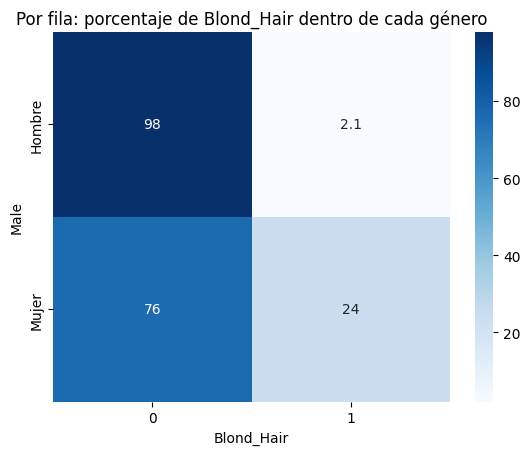

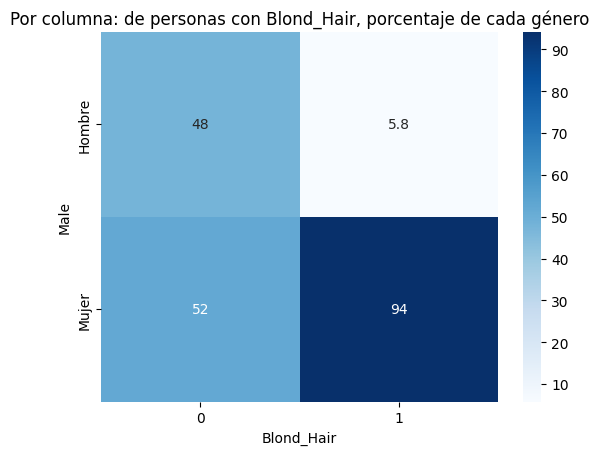

In [ ]:
df_hombres, df_mujeres = filtrar_por_atributo(df, "Male")
df_sonrien, df_no_sonrien = filtrar_por_atributo(df, "Smiling")
df_rubios, df_no_rubios = filtrar_por_atributo(df, "Blond_Hair")
df_anteojos, df_no_anteojos = filtrar_por_atributo(df, "Eyeglasses")
df_mujeres_con_anteojos, df_mujeres_sin_anteojos = filtrar_por_atributo(df_mujeres, "Eyeglasses")
relacion_atributos(df, "Male", "Blond_Hair")
#esta bien esta interpretacion? : quiero predecir con un modelo basico el genero a partir de color de pelo. si el ejemplo es rubio, 
#entonces con un 94% de probabilidad es mujer, y 5.8% varon.   

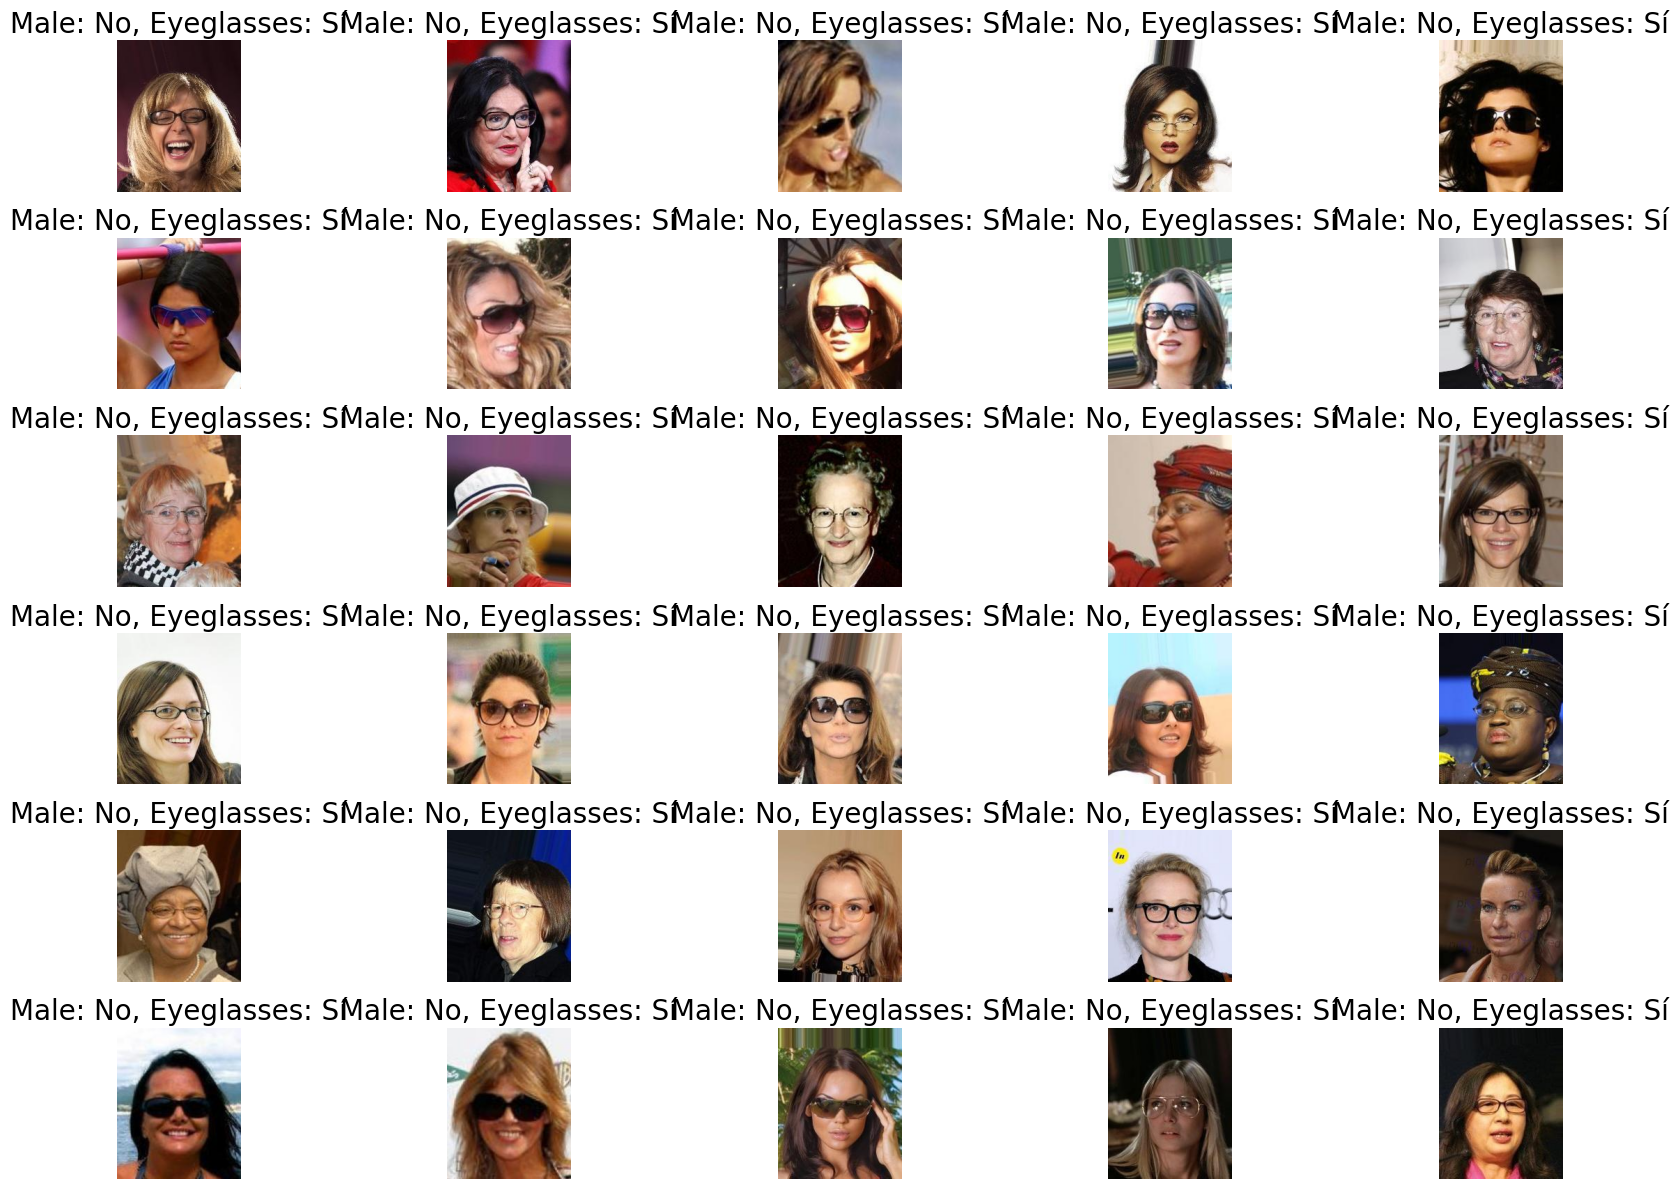

In [221]:
sampleo(df_mujeres_con_anteojos, 30, "Male", "Eyeglasses")

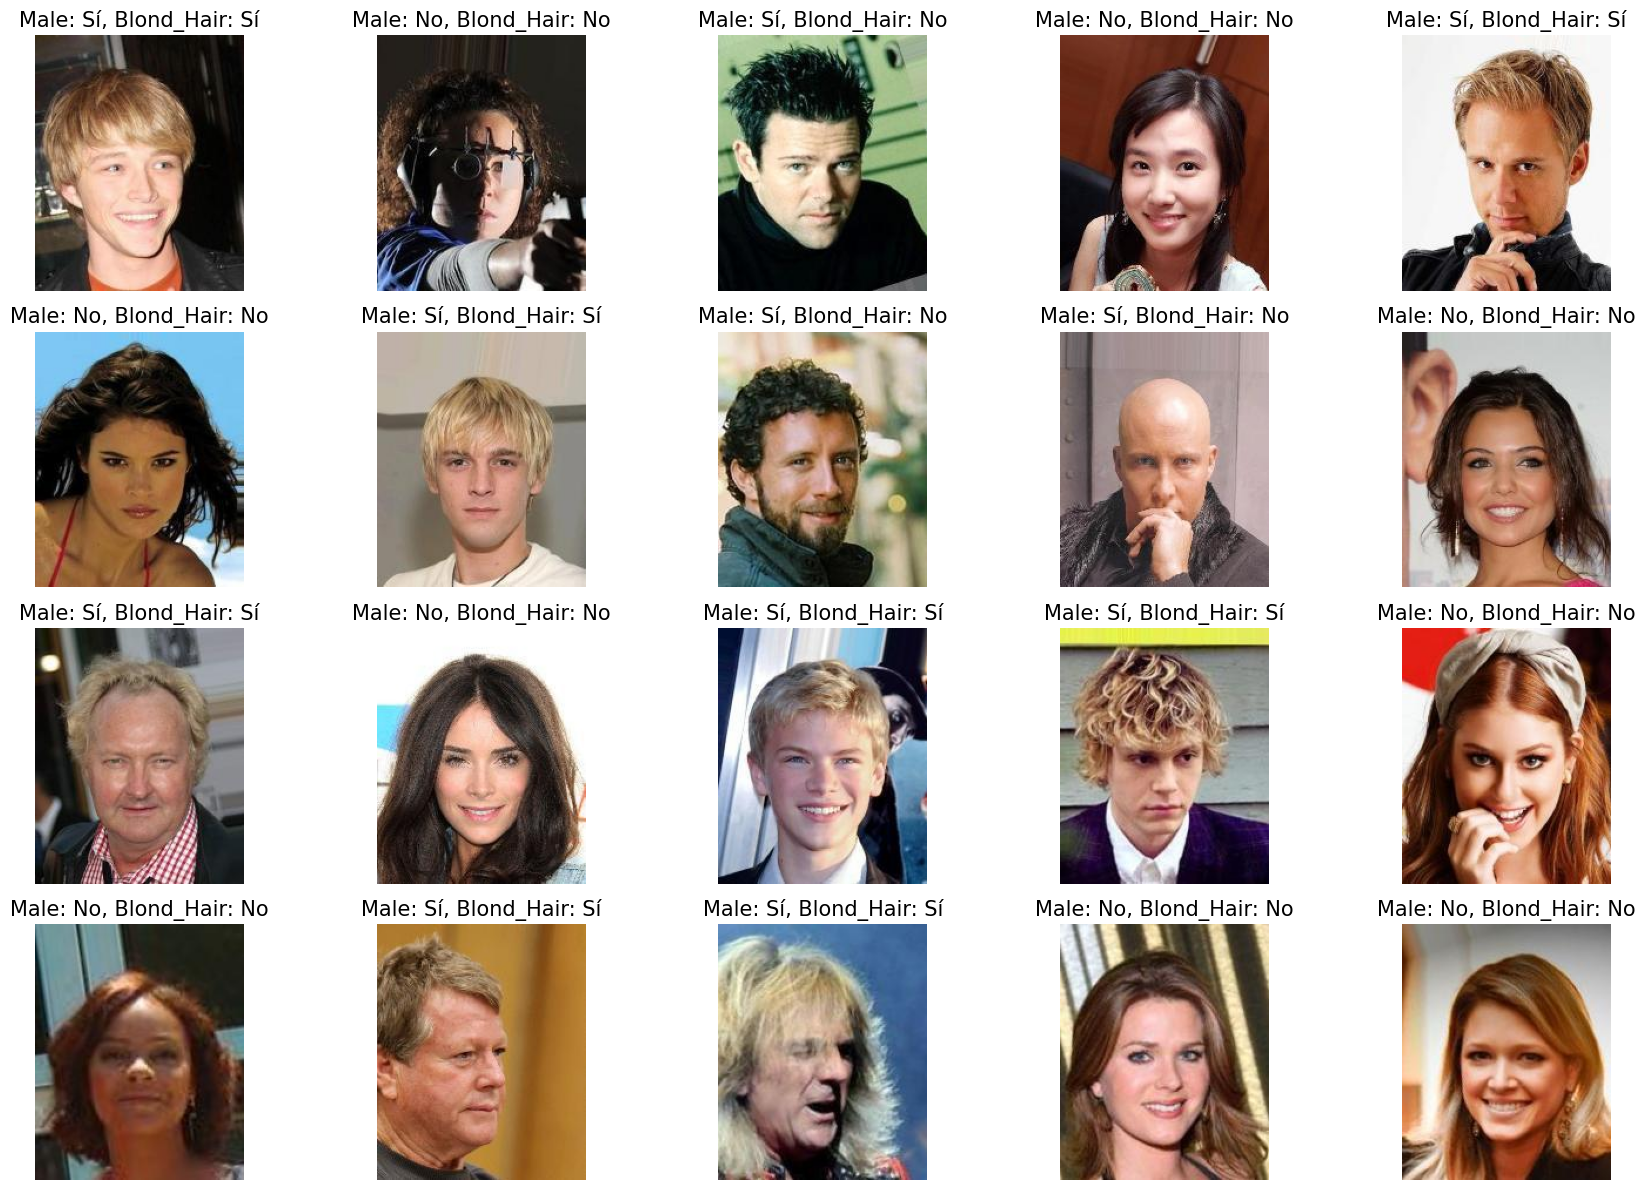

In [231]:
proporciones = {
    (1, 1): 0.3,   # Hombre con anteojos
    (1, 0): 0.2,   # Hombre sin anteojos
    (0, 1): 0,   # Mujer con anteojos
    (0, 0): 0.5    # Mujer sin anteojos
}

df_todas_mujeres_con_anteojos = sampleo_por_atributos(df, "Male", "Blond_Hair", proporciones, n_total=5000)
sampleo(df_todas_mujeres_con_anteojos, 20, "Male","Blond_Hair")